In [1]:
import numpy as np
from Utils import CanonicalUnits, Kepler, GravitationalParameters, X2E, computeNumericalJacobian, OrbitTrasformations
import spiceypy as spy
import scipy.optimize as optimize
from typing import Dict, Set, Optional, Union, Tuple
import seaborn as sns
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
%load_ext autoreload 
%autoreload 2

In [2]:
deg = np.pi/180
AU_m = 1.496e11 #m
M_sun = 1.9891e30
G = 6.67430e-11 # m^3 / (kg s^2)
year = 365.25*24*3600 #s
mu = CanonicalUnits().mu
grav_params = GravitationalParameters(mu=mu)

In [3]:
def compute_functions(i: float, w: float, Omega: float, 
                    which: Set[str]) -> Dict[str, float]:
    """Compute transformation functions A, B, C, D, F, G"""
    results = {}
    
    if 'A' in which:
        results['A'] = (np.cos(Omega)*np.cos(w) - np.sin(Omega)*np.cos(i)*np.sin(w))
    if 'B' in which:
        results['B'] = (-np.cos(Omega)*np.sin(w) - np.sin(Omega)*np.cos(i)*np.cos(w))
    if 'C' in which:
        results['C'] = (np.sin(Omega)*np.cos(w) + np.cos(Omega)*np.cos(i)*np.sin(w))
    if 'D' in which:
        results['D'] = (-np.sin(Omega)*np.sin(w) + np.cos(Omega)*np.cos(i)*np.cos(w))
    if 'F' in which:
        results['F'] = np.sin(w) * np.sin(i)
    if 'G' in which:
        results['G'] = np.cos(w) * np.sin(i)
    
    return results

def compute_state_vector(E: np.array, mu: float) -> np.array:
    state_vector = spy.conics(E+[0, mu], 0)
    return state_vector

def jacobian_XoE(a: float, e: float, i: float, Omega: float, w: float, M: float, mu: float) -> np.array:
    E = optimize.newton(Kepler, M, args=(M, e))

    functions = compute_functions(i, w, Omega, {'A', 'B', 'C', 'D', 'F', 'G'})
    A = functions['A']
    B = functions['B']
    C = functions['C']
    D = functions['D']
    F = functions['F']
    G = functions['G']
    
    ot = OrbitTrasformations()
    r = ot.r(a, e, E)
    eps = ot.sqrt_e(e)
    nu = ot.nu(a, mu)
    nur = nu/r

    q = a*(1-e)
    state_vector = compute_state_vector([q, e, i, Omega, w, M], mu)

    #partial a

    partial_a_x = state_vector[0]/a
    partial_a_y = state_vector[1]/a
    partial_a_z = state_vector[2]/a
    partial_a_vx = -state_vector[3]/(2*a)
    partial_a_vy = -state_vector[4]/(2*a)
    partial_a_vz = -state_vector[5]/(2*a)

    partial_a = [partial_a_x, partial_a_y, partial_a_z, partial_a_vx, partial_a_vy, partial_a_vz]

    #partial e

    #dX/de
    dcosEde=-a*np.sin(E)**2/r       
    dsinEde=a*np.cos(E)*np.sin(E)/r
    dnurde=(nu*a/r**2)*(np.cos(E)-(a/r)*e*np.sin(E)**2)
    depsde=-e/eps

    drAde=a*(dcosEde-1)
    drBde=a*(depsde*np.sin(E)+eps*dsinEde)

    dvAde=-(dnurde*np.sin(E)+nur*dsinEde)
    dvBde=(dnurde*eps*np.cos(E)+nur*depsde*np.cos(E)+nur*eps*dcosEde)

    partial_e = np.array([
        drAde*A+drBde*B,
        drAde*C+drBde*D,
        drAde*F+drBde*G,
        dvAde*A+dvBde*B,
        dvAde*C+dvBde*D,
        dvAde*F+dvBde*G
    ])

    #partial i
    partial_i_x = state_vector[2]*np.sin(Omega)
    partial_i_y = -state_vector[2]*np.cos(Omega)
    partial_i_z = -state_vector[0]*np.sin(Omega) + state_vector[1]*np.cos(Omega)

    partial_i_vx = state_vector[5]*np.sin(Omega)
    partial_i_vy = -state_vector[5]*np.cos(Omega)
    partial_i_vz = -state_vector[3]*np.sin(Omega) + state_vector[4]*np.cos(Omega)

    partial_i = [partial_i_x, partial_i_y, partial_i_z, partial_i_vx, partial_i_vy, partial_i_vz]

    #partial Omega
    partial_Omega_x = -state_vector[1]
    partial_Omega_y = state_vector[0]
    partial_Omega_z = 0

    partial_Omega_vx = -state_vector[4]
    partial_Omega_vy = state_vector[3]
    partial_Omega_vz = 0

    partial_Omega = [partial_Omega_x, partial_Omega_y, partial_Omega_z, partial_Omega_vx, partial_Omega_vy, partial_Omega_vz]

    #partial w

    partial_w_x = -state_vector[1]*np.cos(i) - state_vector[2]*np.sin(i)*np.cos(Omega)
    partial_w_y = state_vector[0]*np.cos(i) - state_vector[2]*np.sin(i)*np.sin(Omega)
    partial_w_z = state_vector[0]*np.sin(i)*np.cos(Omega) + state_vector[1]*np.sin(i)*np.sin(Omega)
    partial_w_vx = -state_vector[4]*np.cos(i) - state_vector[5]*np.sin(i)*np.cos(Omega)
    partial_w_vy = state_vector[3]*np.cos(i) - state_vector[5]*np.sin(i)*np.sin(Omega)
    partial_w_vz = state_vector[3]*np.sin(i)*np.cos(Omega) + state_vector[4]*np.sin(i)*np.sin(Omega)

    partial_w = [partial_w_x, partial_w_y, partial_w_z, partial_w_vx, partial_w_vy, partial_w_vz]

    #partial M
    n = (mu/a**3)**0.5
    factor = -(mu*a**3)**0.5/r**3

    partial_M_x = (1/n) * state_vector[3]
    partial_M_y = (1/n) * state_vector[4]
    partial_M_z = (1/n) * state_vector[5]
    partial_M_vx = factor * state_vector[0]
    partial_M_vy = factor * state_vector[1]
    partial_M_vz = factor * state_vector[2]

    partial_M = [partial_M_x, partial_M_y, partial_M_z, partial_M_vx, partial_M_vy, partial_M_vz]

    J = np.zeros((6,6))
    J[:,0] = partial_a
    J[:,1] = partial_e
    J[:,2] = partial_i
    J[:,3] = partial_Omega
    J[:,4] = partial_w
    J[:,5] = partial_M
    
    return J

In [4]:
a = 0.5
e = 0.1
i = np.pi/2
Omega = np.pi
w = np.pi
M = np.pi
q = a*(1-e)

J = jacobian_XoE(a,e,i,w,Omega,M,mu)

Je2c=np.eye(6)
Je2c[0,0]=1/(1-e)
Je2c[0,1]=q/(1-e)**2
Jq=np.matmul(J,Je2c)
Jq

array([[-1.22222222e+00, -1.11111111e+00,  1.25333620e-31,
        -6.73555740e-17,  1.02342668e-15,  8.98241160e-16],
       [ 1.49679053e-16,  1.36071867e-16,  1.02342668e-15,
        -5.50000000e-01, -3.36777870e-17, -2.76933677e-17],
       [ 2.27428151e-15,  1.13744923e-15,  6.16297582e-32,
         0.00000000e+00,  5.50000000e-01,  4.52267017e-01],
       [-1.77391654e-14, -6.07629559e-15,  9.84438316e-16,
         4.92219158e-16,  8.03854889e+00,  7.34458692e+00],
       [ 5.46910176e-16,  7.70646157e-16,  8.03854889e+00,
         1.59652489e-14, -9.84438316e-16, -8.99452486e-16],
       [-8.93172099e+00, -1.25856068e+01,  4.92219158e-16,
         0.00000000e+00, -1.59652489e-14, -1.36666294e-14]])

In [5]:
J

array([[-1.10000000e+00, -5.00000000e-01,  1.25333620e-31,
        -6.73555740e-17,  1.02342668e-15,  8.98241160e-16],
       [ 1.34711148e-16,  6.12323400e-17,  1.02342668e-15,
        -5.50000000e-01, -3.36777870e-17, -2.76933677e-17],
       [ 2.04685336e-15,  3.08477217e-19,  6.16297582e-32,
         0.00000000e+00,  5.50000000e-01,  4.52267017e-01],
       [-1.59652489e-14,  2.79328711e-15,  9.84438316e-16,
         4.92219158e-16,  8.03854889e+00,  7.34458692e+00],
       [ 4.92219158e-16,  4.97191069e-16,  8.03854889e+00,
         1.59652489e-14, -9.84438316e-16, -8.99452486e-16],
       [-8.03854889e+00, -8.11974635e+00,  4.92219158e-16,
         0.00000000e+00, -1.59652489e-14, -1.36666294e-14]])

In [6]:
E = [q, e, i, Omega, w, M]
E2X = lambda E, mu: spy.conics(E+[0, mu], 0)
dX=np.array([1e-3]*6)
args=dict(mu=mu)
E_num, JXoE_comp=computeNumericalJacobian(E2X,E,dX,**args)
JXoE_comp

array([[-1.22222222e+00, -1.11111248e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00, -1.11022302e-13],
       [ 1.49679053e-16,  1.36072035e-16,  2.05339955e-16,
        -5.49999908e-01, -3.36777814e-17, -2.76933643e-17],
       [-1.36952207e-13, -2.72707654e-13,  0.00000000e+00,
         0.00000000e+00,  5.49999908e-01,  4.52266960e-01],
       [-3.58961694e-12, -1.79880252e-12,  9.84438152e-16,
         4.92219076e-16,  8.03854755e+00,  7.34458628e+00],
       [ 5.46911864e-16,  7.70646442e-16,  8.03854755e+00,
         5.20179705e-15, -9.84438152e-16, -8.99452407e-16],
       [-8.93174855e+00, -1.25856115e+01,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

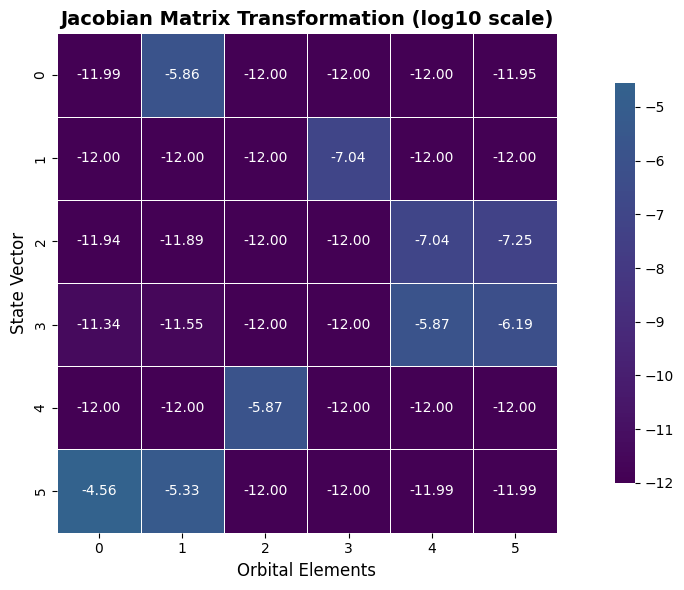

In [7]:
plt.figure(figsize=(12, 6))

# Apply log10 to absolute values, add epsilon to avoid log(0)
eps = 1e-12
data_log = np.log10(np.abs(JXoE_comp - Jq) + eps)

# Create heatmap
sns.heatmap(data_log, 
            annot=True, 
            fmt='.2f',   # no need for scientific notation, since log scale
            cmap='viridis', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": .8})

plt.title(f'Jacobian Matrix Transformation (log10 scale)', fontsize=14, fontweight='bold')
plt.xlabel('Orbital Elements', fontsize=12)
plt.ylabel('State Vector', fontsize=12)
plt.tight_layout()
plt.show()

In [8]:
def trasformation_E_to_X(a: float, e: float, i: float, Omega: float, w: float, M: float, mu: float) -> tuple[float, float, float, float, float, float]:
    q = a*(1-e)

    state_vec = compute_state_vector([q, e, i, Omega, w, M], mu)
    x = state_vec[0]
    y = state_vec[1]
    z = state_vec[2]
    vx = state_vec[3]
    vy = state_vec[4]
    vz = state_vec[5]

    return x, y, z, vx, vy, vz

def trasformation_X_to_E(x: float, y: float, z: float, vx: float, vy: float, vz: float, mu: float) -> tuple[float, float, float, float, float, float]:

    elements = spy.oscelt([x, y, z, vx, vy, vz], et=0, mu=mu)
    q = elements[0]
    e = elements[1]
    i = elements[2]
    Omega = elements[3]
    w = elements[4]
    M = elements[5]
    a = q/(1-e)

    return a, e, i, Omega, w, M

In [9]:
N = int(1e7)

file_state = f"../datos/random_uniform_elements/state_vector_N{N}.dat"
file_elements = f"../datos/random_uniform_elements/elements_N{N}.dat"

if not os.path.isfile(file_elements) or not os.path.isfile(file_state) or 1:
    print(f"Generating elements")
    a_uniform = np.random.uniform(0, 2, N)
    e_uniform = np.random.uniform(0, 1, N)
    i_uniform = np.random.uniform(0, np.pi, N)
    Omega_uniform = np.random.uniform(0, 2*np.pi, N)
    w_uniform = np.random.uniform(0, 2*np.pi, N)
    M_uniform = np.random.uniform(0, 2*np.pi, N)
    q_uniform = a_uniform*(1-e_uniform)

    elements = np.column_stack((a_uniform, e_uniform, i_uniform, Omega_uniform, w_uniform, M_uniform, q_uniform))

    np.savetxt(file_elements, elements)

    print("Generation state vector")
    state_vectors = np.zeros((N, 6))
    for el in tqdm(range(N)):
        a = a_uniform[el]
        e = e_uniform[el]
        i = i_uniform[el]
        Omega = Omega_uniform[el]
        w = w_uniform[el]
        M = M_uniform[el]

        x, y, z, vx, vy, vz = trasformation_E_to_X(a, e, i, Omega, w, M, mu)
        state_vectors[el] = np.array([x, y, z, vx, vy, vz])

    np.savetxt(file_state, state_vectors)
else:
    print('data vectors already generated')
    print('Loading files') 
    state_vectors = np.loadtxt(file_state)
    elements = np.loadtxt(file_elements)      

Generating elements
Generation state vector


100%|██████████| 10000000/10000000 [01:33<00:00, 106452.02it/s]


In [10]:
state_vectors

array([[ 1.67645513e-03, -1.38959585e-02,  2.94820890e-04,
         5.18676217e+00,  5.23125442e+00, -5.36280587e+01],
       [ 1.24481511e+00, -3.22998726e+00, -2.11099621e-01,
         1.02459702e+00,  6.84157997e-01, -1.69677186e-01],
       [-9.54875153e-01, -9.78632831e-01, -1.41416856e-01,
        -8.12383172e-03, -5.12031777e+00, -1.82477822e+00],
       ...,
       [-1.24081500e+00,  3.09121412e-01, -8.35380075e-01,
         1.26329303e-01, -4.81017444e+00, -1.53698547e+00],
       [-1.73415172e+00,  9.27665540e-01,  5.94374152e-01,
        -2.83063964e-01, -5.04900186e-01, -3.68344481e+00],
       [ 9.83491108e-01,  2.30491523e-01, -1.20906225e+00,
        -1.49992643e+00, -3.31994606e+00, -3.35829805e+00]])

In [11]:
def P_E() -> float:
    a_max = 2; a_min = 0
    e_max = 1; e_min = 0
    i_max = np.pi; i_min = 0
    Omega_max = 2*np.pi; Omega_min = 0
    w_max = 2*np.pi; w_min = 0
    M_max = 2*np.pi; M_min = 0

    return 1/(a_max - a_min) * 1/(e_max - e_min) * 1/(i_max - i_min) * 1/(Omega_max - Omega_min) * 1/(w_max - w_min) * 1/(M_max - M_min)

def P_X(x: float, y: float, z: float, vx: float, vy: float, vz: float) -> float:
    a, e, i, Omega, w, M = trasformation_X_to_E(x, y, z, vx, vy, vz, mu)
    J = jacobian_XoE(a,e,i,Omega,w,M,mu)
    det = np.linalg.det(J)
    #print(det)
    inv_det = 1.0/det
    P = P_E() * abs(inv_det)
    return P

def P_X_vectorized(x: np.array, y: np.array, z: np.array, vx: np.array, vy: np.array, vz: np.array, mu: float) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    vx = np.asarray(vx)
    vy = np.asarray(vy)
    vz = np.asarray(vz)
    # Prepare output array
    shape = np.broadcast(x, y, z, vx, vy, vz).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    z_flat = z.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()
    vz_flat = vz.ravel()

    for idx in range(x_flat.size):
        a, e, i, Omega, w, M = trasformation_X_to_E(x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx], mu)
        J = jacobian_XoE(a,e,i,Omega,w,M,mu)
        det = np.linalg.det(J)
        inv_det = 1.0/det
        P.flat[idx] = P_E() * abs(inv_det)

    return P.reshape(shape)

In [12]:
def surface_integral_P_X(center, widths, n_points=8, mu=1):
    """
    Calculate the surface integral of P_xyvxvy in a hypercube centered at (x, y, vx, vy)
    with dimensions (dx, dy, dvx, dvy) using Gauss-Legendre quadrature.

    Parameters:
        center: tuple/list/array of (x, y, vx, vy) center
        widths: tuple/list/array of (dx, dy, dvx, dvy) side lengths
        n_points: number of quadrature points per dimension

    Returns:
        Integral (float)
    """
    from numpy.polynomial.legendre import leggauss

    x0, y0, z0, vx0, vy0, vz0 = center
    dx, dy, dz, dvx, dvy, dvz = widths

    # Get Gauss-Legendre points and weights for [-1, 1]
    pts, wts = leggauss(n_points)

    # Map points from [-1, 1] to [center-width/2, center+width/2] for each dimension
    x_pts = x0 + 0.5*dx*pts
    y_pts = y0 + 0.5*dy*pts
    z_pts = z0 + 0.5*dz*pts
    vx_pts = vx0 + 0.5*dvx*pts
    vy_pts = vy0 + 0.5*dvy*pts
    vz_pts = vz0 + 0.5*dvz*pts

    # Create meshgrid of all quadrature points
    X, Y, Z, VX, VY, VZ = np.meshgrid(x_pts, y_pts, z_pts, vx_pts, vy_pts, vz_pts, indexing='ij')
    WX, WY, WZ, WVX, WVY, WVZ = np.meshgrid(wts, wts, wts, wts, wts, wts, indexing='ij')

    # Flatten for vectorized evaluation
    Xf = X.ravel()
    Yf = Y.ravel()
    Zf = Z.ravel()
    VXf = VX.ravel()
    VYf = VY.ravel()
    VZf = VZ.ravel()
    WF = (WX * WY * WZ * WVX * WVY * WVZ).ravel()
    # Evaluate P at all points
    Pf = P_X_vectorized(Xf, Yf, Zf, VXf, VYf, VZf, mu)

    # Integral is sum(P * weight) * volume factor
    integral = np.sum(Pf * WF) * (0.5*dx) * (0.5*dy) * (0.5*dz) * (0.5*dvx) * (0.5*dvy) * (0.5*dvz)
    #return integral, y_points
    return integral

In [13]:
# Define center and widths of the phase-space hypercube
c_x = 1
c_y = 0
c_z = 0
v_x = 0
v_y = (mu/1)**0.5
v_z = 0

dxyz = 0.2
dvxyz = 5000 * (1/AU_m) * year 

center = (c_x, c_y, c_z, v_x, v_y, v_z)
widths = (dxyz, dxyz, dxyz, dvxyz, dvxyz, dvxyz)

# Theoretical: compute expected number of objects in the volume by integrating the distribution
N_theoretical = surface_integral_P_X(center, widths, n_points=8, mu=mu)
print(f"Theoretical (integral) number of objects in volume: {N_theoretical * N}")

# Numerical: count number of objects in the volume from the sample
objsx = (abs(state_vectors[:,0] - c_x) <= dxyz/2) 
objsy = (abs(state_vectors[:,1] - c_y) <= dxyz/2) 
objsz = (abs(state_vectors[:,2] - c_z) <= dxyz/2) 
objsvx = (abs(state_vectors[:,3] - v_x) <= dvxyz/2) 
objsvy = (abs(state_vectors[:,4] - v_y) <= dvxyz/2) 
objsvz = (abs(state_vectors[:,5] - v_z) <= dvxyz/2) 

objects = objsx & objsy & objsz & objsvx & objsvy & objsvz
N_numeric = objects.sum()
print(f'Numerical (count) number of objects inside volume: {N_numeric}')
print('Ratio', (N_theoretical * N)/N_numeric)

Theoretical (integral) number of objects in volume: 105.25428344142887
Numerical (count) number of objects inside volume: 121
Ratio 0.869870111086189


Usando derivada numerica 

In [14]:
def CompJacobian_XoE(a: float, e: float, i: float, Omega: float, w: float, M: float, mu: float):
    q = a*(1-e)
    E = [q, e, i, Omega, w, M]
    E2X = lambda E, mu: spy.conics(E+[0, mu], 0)
    dX=np.array([1e-3]*6)
    args=dict(mu=mu)
    E_num, JXoE_comp=computeNumericalJacobian(E2X,E,dX,**args)

    Je2c=np.eye(6)
    Je2c[0,0]=(1-e)
    Je2c[0,1]=-a
    Ja=np.matmul(JXoE_comp,Je2c)
    return Ja

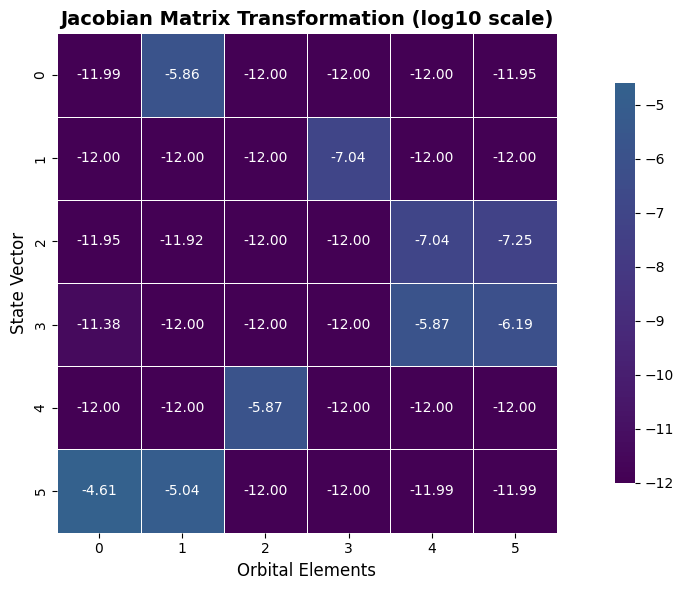

In [15]:
a = 0.5
e = 0.1
i = np.pi/2
Omega = np.pi
w = np.pi
M = np.pi
q = a*(1-e)

J = jacobian_XoE(a,e,i,w,Omega,M,mu)
Jnum = CompJacobian_XoE(a,e,i,Omega,w,M,mu)

eps = 1e-12
data_log = np.log10(np.abs(Jnum - J) + eps)

plt.figure(figsize=(12, 6))

# Create heatmap
sns.heatmap(data_log, 
            annot=True, 
            fmt='.2f',   # no need for scientific notation, since log scale
            cmap='viridis', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": .8})

plt.title(f'Jacobian Matrix Transformation (log10 scale)', fontsize=14, fontweight='bold')
plt.xlabel('Orbital Elements', fontsize=12)
plt.ylabel('State Vector', fontsize=12)
plt.tight_layout()
plt.show()


In [16]:
def computeNumericalJacobian(jfun,x,dx,**args):
    """
    Computes numerically the Jacobian matrix of a multivariate function.

    Parameters:
        jfun: multivariate function with the prototype "def jfun(x,**args)", function
        x: indepedent variables, numpy array (N).
        dx: step size of independent variables, numpy array (N).
        **args: argument of the function

    Return:
        y: dependent variables, y=jfun(x,**args)
        Jyx: Jacobian matrix:

            Jif= [dy_1/dx_1,dy_1/dx_2,...,dy_1/dx_N,
                dy_2/dx_1,dy_2/dx_2,...,dy_2/dx_N,
                                . . .
                dy_N/dx_1,dy_N/dx_2,...,dy_N/dx_N,]
    """
    N=len(x)
    J=np.zeros((N,N))
    y=jfun(x,**args)
    for i in range(N):
        for j in range(N):
            pre=[x[k] for k in range(j)]
            pos=[x[k] for k in range(j+1,N)]
            yi=lambda t:jfun(pre+[t]+pos,**args)[i]
            dyidxj=(yi(x[j]+dx[j])-yi(x[j]-dx[j]))/(2*dx[j])
            J[i,j]=dyidxj
    return y,J


In [17]:
def trasformation_E_to_X(q: float, e: float, i: float, Omega: float, w: float, M: float, mu: float) -> tuple[float, float, float, float, float, float]:

    state_vec = spy.conics([q, e, i, Omega, w, M]+[0, mu], 0)
    x = state_vec[0]
    y = state_vec[1]
    z = state_vec[2]
    vx = state_vec[3]
    vy = state_vec[4]
    vz = state_vec[5]

    return x, y, z, vx, vy, vz

def trasformation_X_to_E(x: float, y: float, z: float, vx: float, vy: float, vz: float, mu: float) -> tuple[float, float, float, float, float, float]:

    elements = spy.oscelt([x, y, z, vx, vy, vz], et=0, mu=mu)
    q = elements[0]
    e = elements[1]
    i = elements[2]
    Omega = elements[3]
    w = elements[4]
    M = elements[5]

    return q, e, i, Omega, w, M

In [18]:
def E2X(E: list[float], mu: float) -> list[float]:
    if E[1] > 0:
        return spy.conics(E+[0, mu], 0)
    else:
        E[1] = 0
        return spy.conics(E+[0, mu], 0)

def P_E() -> float:
    q_max = 1.3; q_min = 0
    e_max = 1; e_min = 0
    i_max = np.pi; i_min = 0
    Omega_max = 2*np.pi; Omega_min = 0
    w_max = 2*np.pi; w_min = 0
    M_max = 2*np.pi; M_min = 0

    return 1/(q_max - q_min) * 1/(e_max - e_min) * 1/(i_max - i_min) * 1/(Omega_max - Omega_min) * 1/(w_max - w_min) * 1/(M_max - M_min)

def P_X(x: float, y: float, z: float, vx: float, vy: float, vz: float) -> float:
    q, e, i, Omega, w, M = trasformation_X_to_E(x, y, z, vx, vy, vz, mu)
    E = [q, e, i, Omega, w, M]
    dX=np.array([1e-3]*6)
    args=dict(mu=mu)
    E_num, J=computeNumericalJacobian(E2X,E,dX,**args)
    #det = np.linalg.det(J)
    det = 1.0/np.linalg.det(J)
    P = P_E() * abs(det)
    return P

def P_X_vectorized(x: np.array, y: np.array, z: np.array, vx: np.array, vy: np.array, vz: np.array, mu: float) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    vx = np.asarray(vx)
    vy = np.asarray(vy)
    vz = np.asarray(vz)
    # Prepare output array
    shape = np.broadcast(x, y, z, vx, vy, vz).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    z_flat = z.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()
    vz_flat = vz.ravel()

    for idx in range(x_flat.size):
        q, e, i, Omega, w, M = trasformation_X_to_E(x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx], mu)
        E = [q, e, i, Omega, w, M]
        dX=np.array([1e-3]*6)
        args=dict(mu=mu)
        E_num, J=computeNumericalJacobian(E2X,E,dX,**args)
        #det = np.linalg.det(J)/(1-e)
        det = 1.0/np.linalg.det(J)
        P.flat[idx] = P_E() * abs(det)

    return P.reshape(shape)

In [19]:
def surface_integral_P_X(center, widths, n_points=8, mu=1):
    """
    Calculate the surface integral of P_xyvxvy in a hypercube centered at (x, y, vx, vy)
    with dimensions (dx, dy, dvx, dvy) using Gauss-Legendre quadrature.

    Parameters:
        center: tuple/list/array of (x, y, vx, vy) center
        widths: tuple/list/array of (dx, dy, dvx, dvy) side lengths
        n_points: number of quadrature points per dimension

    Returns:
        Integral (float)
    """
    from numpy.polynomial.legendre import leggauss

    x0, y0, z0, vx0, vy0, vz0 = center
    dx, dy, dz, dvx, dvy, dvz = widths

    # Get Gauss-Legendre points and weights for [-1, 1]
    pts, wts = leggauss(n_points)

    # Map points from [-1, 1] to [center-width/2, center+width/2] for each dimension
    x_pts = x0 + 0.5*dx*pts
    y_pts = y0 + 0.5*dy*pts
    z_pts = z0 + 0.5*dz*pts
    vx_pts = vx0 + 0.5*dvx*pts
    vy_pts = vy0 + 0.5*dvy*pts
    vz_pts = vz0 + 0.5*dvz*pts

    # Create meshgrid of all quadrature points
    X, Y, Z, VX, VY, VZ = np.meshgrid(x_pts, y_pts, z_pts, vx_pts, vy_pts, vz_pts, indexing='ij')
    WX, WY, WZ, WVX, WVY, WVZ = np.meshgrid(wts, wts, wts, wts, wts, wts, indexing='ij')

    # Flatten for vectorized evaluation
    Xf = X.ravel()
    Yf = Y.ravel()
    Zf = Z.ravel()
    VXf = VX.ravel()
    VYf = VY.ravel()
    VZf = VZ.ravel()
    WF = (WX * WY * WZ * WVX * WVY * WVZ).ravel()

    # Evaluate P at all points
    Pf = P_X_vectorized(Xf, Yf, Zf, VXf, VYf, VZf, mu)

    # Integral is sum(P * weight) * volume factor
    integral = np.sum(Pf * WF) * (0.5*dx) * (0.5*dy) * (0.5*dz) * (0.5*dvx) * (0.5*dvy) * (0.5*dvz)
    return integral

In [ ]:
N = int(1e7)

q_uniform = np.random.uniform(0, 1.3, N)
e_uniform = np.random.uniform(0, 1, N)
i_uniform = np.random.uniform(0, np.pi, N)
Omega_uniform = np.random.uniform(0, 2*np.pi, N)
w_uniform = np.random.uniform(0, 2*np.pi, N)
M_uniform = np.random.uniform(0, 2*np.pi, N)
q_uniform = a_uniform*(1-e_uniform)

state_vectors = np.zeros((N, 6))
for el in tqdm(range(N)):
    q = q_uniform[el]
    e = e_uniform[el]
    i = i_uniform[el]
    Omega = Omega_uniform[el]
    w = w_uniform[el]
    M = M_uniform[el]

    x, y, z, vx, vy, vz = trasformation_E_to_X(q, e, i, Omega, w, M, mu)
    state_vectors[el] = np.array([x, y, z, vx, vy, vz])

 58%|█████▊    | 5829230/10000000 [00:53<00:40, 103364.35it/s]

In [ ]:
# Define center and widths of the phase-space hypercube
c_x = 1
c_y = 0
c_z = 0
v_x = 0
v_y = (mu/1)**0.5
v_z = 0

dxyz = 0.2
dvxyz = 5000 * (1/AU_m) * year 

center = (c_x, c_y, c_z, v_x, v_y, v_z)
widths = (dxyz, dxyz, dxyz, dvxyz, dvxyz, dvxyz)

# Theoretical: compute expected number of objects in the volume by integrating the distribution
N_theoretical = surface_integral_P_X(center, widths, n_points=8, mu=mu)
print(f"Theoretical (integral) number of objects in volume: {N_theoretical * N}")

# Numerical: count number of objects in the volume from the sample
objsx = (abs(state_vectors[:,0] - c_x) <= dxyz/2) 
objsy = (abs(state_vectors[:,1] - c_y) <= dxyz/2) 
objsz = (abs(state_vectors[:,2] - c_z) <= dxyz/2) 
objsvx = (abs(state_vectors[:,3] - v_x) <= dvxyz/2) 
objsvy = (abs(state_vectors[:,4] - v_y) <= dvxyz/2) 
objsvz = (abs(state_vectors[:,5] - v_z) <= dvxyz/2) 

objects = objsx & objsy & objsz & objsvx & objsvy & objsvz
N_numeric = objects.sum()
print(f'Numerical (count) number of objects inside volume: {N_numeric}')
print('Ratio', (N_theoretical * N)/N_numeric)

Theoretical (integral) number of objects in volume: 149.299002649964
Numerical (count) number of objects inside volume: 107
Ratio 1.3953177817753644


In [ ]:
#distribuciones no uniforme, agregar jacobiano 

### Test using Toroid Trasformation

In [ ]:
def calculate_jacobian_torus_to_r3(point, R, r):
    """
    Calculates the Jacobian matrix of the transformation from Torus to R^3 at a given point.
    """
    x, y, z = point
    #R = (a + b) / 2.0
    #r = (b - a) / 2.0

    # Handle singularity at the z-axis
    r_xy = np.sqrt(x**2 + y**2)
    if r_xy < 1e-9: # Avoid division by zero
        # The Jacobian is not well-defined on the z-axis, but we can return a limit
        # For simplicity, we'll state it's undefined for this example.
        print("Warning: Jacobian is not well-defined on the z-axis.")
        return np.full((3, 3), np.nan)

    s = np.sqrt((r_xy - R)**2 + z**2)
    if s < 1e-9: # Avoid division by zero at the central circle
        print("Warning: Jacobian is not well-defined on the central circle.")
        return np.full((3, 3), np.nan)

    # Scaling function and its derivative
    f_s = np.tan((np.pi / 2.0) * (s / r))
    f_prime_s = (np.pi / (2.0 * r)) * (1.0 / np.cos((np.pi / 2.0) * (s / r))**2)

    # Pre-compute common terms
    term1 = (1 - R / r_xy)
    term2 = f_prime_s - f_s / s

    # Initialize Jacobian matrix
    J = np.zeros((3, 3))

    # Partial derivatives (dx'/dx, dx'/dy, dx'/dz)
    J[0, 0] = (R/r_xy) * (y**2/r_xy**2) + (f_s/s)*term1 + (x**2/s**2) * term1**2 * term2
    J[0, 1] = -(R/r_xy) * (x*y/r_xy**2) + (x*y/s**2) * term1**2 * term2
    J[0, 2] = (x*z/s**2) * ((r_xy - R)/r_xy) * term2

    # Partial derivatives (dy'/dx, dy'/dy, dy'/dz)
    J[1, 0] = -(R/r_xy) * (x*y/r_xy**2) + (x*y/s**2) * term1**2 * term2
    J[1, 1] = (R/r_xy) * (x**2/r_xy**2) + (f_s/s)*term1 + (y**2/s**2) * term1**2 * term2
    J[1, 2] = (y*z/s**2) * ((r_xy - R)/r_xy) * term2

    # Partial derivatives (dz'/dx, dz'/dy, dz'/dz)
    J[2, 0] = (x*z/s**2) * ((r_xy - R)/r_xy) * term2
    J[2, 1] = (y*z/s**2) * ((r_xy - R)/r_xy) * term2
    J[2, 2] = (f_s/s) + (z**2/s**2) * term2
    
    return J

In [ ]:
def P_X_prime(x: np.array, y: np.array, z: np.array, vx_prime: np.array, vy_prime: np.array, vz_prime: np.array, mu: float, R: float, r: float) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    vx = np.asarray(vx_prime)
    vy = np.asarray(vy_prime)
    vz = np.asarray(vz_prime)
    # Prepare output array
    shape = np.broadcast(x, y, z, vx, vy, vz).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    z_flat = z.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()
    vz_flat = vz.ravel()

    problematic = []
    for idx in range(x_flat.size):
        a, e, i, Omega, w, M = trasformation_X_to_E(x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx], mu)
        J_XoE = jacobian_XoE(a,e,i,Omega,w,M,mu)
        J_VoV_prime = calculate_jacobian_torus_to_r3([vx_flat[idx], vy_flat[idx], vz_flat[idx]], R, r)
        with np.errstate(divide='ignore', invalid='ignore'):
            det_XoE = np.linalg.det(J_XoE) 
            det_VoV_prime = np.linalg.det(J_VoV_prime)

            if det_XoE == 0 or not np.isfinite(det_XoE):
                print('problematic state vector: ', x_flat[idx], y_flat[idx], z_flat[idx],  vx_flat[idx], vy_flat[idx], vz_flat[idx])
                #problematic.append((x_flat[idx], y_flat[idx], z_flat[idx],  vx_flat[idx], vy_flat[idx], vz_flat[idx]))
                P.flat[idx] = np.nan
            else:
                inv_det_XoE = 1.0/det_XoE
                det = det_VoV_prime * inv_det_XoE
                P.flat[idx] = P_E() * abs(det)

    return P.reshape(shape)


In [ ]:
def surface_integral_P_X_prime(center, widths, n_points=8, mu=1, R=1, r=0.5):
    """
    Calculate the surface integral of P_xyvxvy in a hypercube centered at (x, y, vx, vy)
    with dimensions (dx, dy, dvx, dvy) using Gauss-Legendre quadrature.

    Parameters:
        center: tuple/list/array of (x, y, vx, vy) center
        widths: tuple/list/array of (dx, dy, dvx, dvy) side lengths
        n_points: number of quadrature points per dimension

    Returns:
        Integral (float)
    """
    from numpy.polynomial.legendre import leggauss

    x0, y0, z0, vx0, vy0, vz0 = center
    dx, dy, dz, dvx, dvy, dvz = widths

    # Get Gauss-Legendre points and weights for [-1, 1]
    pts, wts = leggauss(n_points)

    # Map points from [-1, 1] to [center-width/2, center+width/2] for each dimension
    x_pts = x0 + 0.5*dx*pts
    y_pts = y0 + 0.5*dy*pts
    z_pts = z0 + 0.5*dz*pts
    vx_pts = vx0 + 0.5*dvx*pts
    vy_pts = vy0 + 0.5*dvy*pts
    vz_pts = vz0 + 0.5*dvz*pts

    # Create meshgrid of all quadrature points
    X, Y, Z, VX, VY, VZ = np.meshgrid(x_pts, y_pts, z_pts, vx_pts, vy_pts, vz_pts, indexing='ij')
    WX, WY, WZ, WVX, WVY, WVZ = np.meshgrid(wts, wts, wts, wts, wts, wts, indexing='ij')

    # Flatten for vectorized evaluation
    Xf = X.ravel()
    Yf = Y.ravel()
    Zf = Z.ravel()
    VXf = VX.ravel()
    VYf = VY.ravel()
    VZf = VZ.ravel()
    WF = (WX * WY * WZ * WVX * WVY * WVZ).ravel()

    # Evaluate P at all points
    Pf = P_X_prime(Xf, Yf, Zf, VXf, VYf, VZf, mu, R, r)

    # Integral is sum(P * weight) * volume factor
    integral = np.sum(Pf * WF) * (0.5*dx) * (0.5*dy) * (0.5*dz) * (0.5*dvx) * (0.5*dvy) * (0.5*dvz)
    return integral

In [ ]:
def map_torus_to_r3(point, r, R):
    """
    Maps a point from the interior of a torus to R^3.

    Args:
        point (tuple or list): The (x, y, z) coordinates of the point inside the torus.
        inner_radius_a (float): The inner radius of the torus.
        outer_radius_b (float): The outer radius of the torus.

    Returns:
        numpy.ndarray: The transformed (x', y', z') coordinates in R^3.
    """
    x, y, z = point

    # 1. Calculate the major and minor radii of the torus
    #R = (inner_radius_a + outer_radius_b) / 2.0
    #r = (outer_radius_b - inner_radius_a) / 2.0

    # Handle the case where the point is on the z-axis to avoid division by zero
    r_xy = np.sqrt(x**2 + y**2)
    if r_xy == 0:
        # If the point is on the z-axis, its projection on the xy-plane is the origin.
        # We can define the corresponding point C on the central circle to be (R, 0, 0).
        C = np.array([R, 0, 0])
    else:
        # 2. Find the corresponding point C on the central circle (in the xy-plane)
        C = np.array([R * x / r_xy, R * y / r_xy, 0])

    # 3. Determine the position vector V within the cross-section
    P = np.array([x, y, z])
    V = P - C

    # 4. Calculate the distance 's' of the point from the central circle
    s = np.linalg.norm(V)

    # If the point is on the central circle, it does not move.
    if s == 0:
        return P

    # 5. Define the scaling function to map the distance to infinity
    # This stretches the distance from the range [0, r) to [0, infinity)
    s_prime = np.tan((np.pi / 2) * (s / r))

    # 6. Construct the transformed point P'
    # The direction from C to P is given by the unit vector V/s
    P_prime = C + s_prime * (V / s)

    return P_prime

In [ ]:
# Define center and widths of the phase-space hypercube
c_x = 1
c_y = 0
c_z = 0
v_x = 0
v_y = (mu/1)**0.5
v_z = 0

dxyz = 0.2
dvxyz = 5000 * (1/AU_m) * year 

center = (c_x, c_y, c_z, v_x, v_y, v_z)
widths = (dxyz, dxyz, dxyz, dvxyz, dvxyz, dvxyz)

#define minor and major radius of the torus
R = 5.5044 #using 99.7% of data in toroid
r = 5.8697 #using 99.7% of data in toroid

# Theoretical: compute expected number of objects in the volume by integrating the distribution
N_theoretical = surface_integral_P_X_prime(center, widths, n_points=8, mu=mu, R=R, r=r)
print(f"Theoretical (integral) number of objects in volume: {N_theoretical * N}")

# Numerical: count number of objects in the volume from the sample
objsx = (abs(state_vectors[:,0] - c_x) <= dxyz/2) 
objsy = (abs(state_vectors[:,1] - c_y) <= dxyz/2) 
objsz = (abs(state_vectors[:,2] - c_z) <= dxyz/2) 
objsvx = (abs(state_vectors[:,3] - v_x) <= dvxyz/2) 
objsvy = (abs(state_vectors[:,4] - v_y) <= dvxyz/2) 
objsvz = (abs(state_vectors[:,5] - v_z) <= dvxyz/2) 

objects = objsx & objsy & objsz & objsvx & objsvy & objsvz
N_numeric = objects.sum()
print(f'Numerical (count) number of objects inside volume: {N_numeric}')
print('Ratio', (N_theoretical * N)/N_numeric)

Theoretical (integral) number of objects in volume: 1.7519570108374818
Numerical (count) number of objects inside volume: 107
Ratio 0.01637343000782693


In [ ]:
state_vectors_prime = np.array([list(map_torus_to_r3(v, r, R)) for v in state_vectors[:,2:5]])

In [ ]:
# Numerical: count number of objects in the volume from the sample
objsx = (abs(state_vectors[:,0] - c_x) <= dxyz/2) 
objsy = (abs(state_vectors[:,1] - c_y) <= dxyz/2) 
objsz = (abs(state_vectors[:,2] - c_z) <= dxyz/2) 
objsvx = (abs(state_vectors_prime[:,0] - v_x) <= dvxyz/2) 
objsvy = (abs(state_vectors_prime[:,1] - v_y) <= dvxyz/2) 
objsvz = (abs(state_vectors_prime[:,2] - v_z) <= dvxyz/2) 

objects = objsx & objsy & objsz & objsvx & objsvy & objsvz
N_numeric = objects.sum()
print(f"Theoretical (integral) number of objects in volume: {N_theoretical * N}")
print(f'Numerical (count) number of objects inside volume: {N_numeric}')
print('Ratio', (N_theoretical * N)/N_numeric)

Theoretical (integral) number of objects in volume: 1.7519570108374818
Numerical (count) number of objects inside volume: 13
Ratio 0.1347659239105755
